In [1]:
import os
from dotenv import load_dotenv
from roboflow import Roboflow

# Carga las variables del archivo .env
load_dotenv()

# Obtiene la API Key de las variables de entorno
ROBOFLOW_KEY = os.getenv("API_ROBOFLOW")
ROBOFLOW_WORKSPACE = os.getenv("API_ROBOFLOW_WORKSPACE")

if not ROBOFLOW_KEY:
    raise ValueError("No se encontró la variable de entorno 'API_ROBOFLOW'. Asegúrate de definirla en tu archivo .env")
rf = Roboflow(api_key=f"{ROBOFLOW_KEY}")
project = rf.workspace("clothesdataset-yimbv").project("deteccion_defectos")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to deteccion_defectos-1 in yolov11:: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 273/273 [00:00<00:00, 1980.50it/s]


In [4]:
dataset.location

'C:\\Users\\USER\\Desktop\\clothes-failures-detection\\Notebooks\\deteccion_defectos-1'

In [7]:
import cv2
import os
import shutil
from pathlib import Path
from tqdm import tqdm

def process_dataset_complete(base_in, base_out, split, clip_limit=3.0, tile_size=(12, 12)):
    """
    Aplica CLAHE a las imágenes y COPIA los labels correspondientes.
    """
    # Definir rutas de entrada
    img_in_dir = Path(base_in) / split / 'images'
    lbl_in_dir = Path(base_in) / split / 'labels'
    
    # Definir rutas de salida
    img_out_dir = Path(base_out) / split / 'images'
    lbl_out_dir = Path(base_out) / split / 'labels'
    
    # Crear carpetas de salida
    img_out_dir.mkdir(parents=True, exist_ok=True)
    lbl_out_dir.mkdir(parents=True, exist_ok=True)

    # Configurar CLAHE
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    
    image_extensions = [".jpg", ".jpeg", ".png"]
    images = [f for f in os.listdir(img_in_dir) if any(f.lower().endswith(ext) for ext in image_extensions)]

    print(f"\n--- Procesando {split.upper()} ---")

    for filename in tqdm(images, desc=f"CLAHE + Labels ({split})"):
        # 1. PROCESAR IMAGEN
        img_path = img_in_dir / filename
        img = cv2.imread(str(img_path))
        
        if img is not None:
            #lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
            #l, a, b = cv2.split(lab)
            #cl = clahe.apply(l)
            #limg = cv2.merge((cl, a, b))
            #final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
            final_img = img
            
            # Guardar imagen procesada
            cv2.imwrite(str(img_out_dir / filename), final_img)

        # 2. COPIAR LABEL (si existe)
        label_filename = Path(filename).stem + ".txt"
        src_label = lbl_in_dir / label_filename
        dst_label = lbl_out_dir / label_filename
        
        if src_label.exists():
            shutil.copy(str(src_label), str(dst_label))

    print(f"Completado: {split}. Imágenes y etiquetas listas en {base_out}/{split}")

# --- CONFIGURACIÓN DE RUTAS ---
# base_in: Donde está tu descarga original de Roboflow
# base_out: Donde quieres tu dataset listo para entrenar
BASE_INPUT = 'deteccion_defectos-1'  
BASE_OUTPUT = 'dataset_final'

for split in ['train', 'valid', 'test']:
    process_dataset_complete(BASE_INPUT, BASE_OUTPUT, split)


--- Procesando TRAIN ---


CLAHE + Labels (train): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 104/104 [00:13<00:00,  7.51it/s]


Completado: train. Imágenes y etiquetas listas en dataset_final/train

--- Procesando VALID ---


CLAHE + Labels (valid): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:02<00:00,  7.47it/s]


Completado: valid. Imágenes y etiquetas listas en dataset_final/valid

--- Procesando TEST ---


CLAHE + Labels (test): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  7.33it/s]

Completado: test. Imágenes y etiquetas listas en dataset_final/test


In [8]:
import albumentations as A
import cv2
import os
from pathlib import Path
from tqdm import tqdm

# Nueva configuración siguiendo las recomendaciones de la librería
transform = A.Compose([
    # 1. 'Affine' reemplaza a ShiftScaleRotate para mayor control
    A.Affine(
        translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
        scale=(0.95, 1.05),
        rotate=(-15, 15),
        p=0.5
    ),
    
    # 2. 'GaussNoise' ahora usa 'std_range' en lugar de 'var_limit'
    A.GaussNoise(std_range=(0.01, 0.05), p=0.3),
    
    # 3. Mantener contraste y brillo
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    
    # 4. Mantener escala de grises para textura
    A.ToGray(p=0.2),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def augment_dataset(img_dir, label_dir, output_img_dir, output_label_dir, n_aug=2):
    Path(output_img_dir).mkdir(parents=True, exist_ok=True)
    Path(output_label_dir).mkdir(parents=True, exist_ok=True)
    
    img_files = list(Path(img_dir).glob("*.jpg"))
    
    for img_path in tqdm(img_files, desc="Augmentando"):
        # Cargar imagen y etiquetas
        image = cv2.imread(str(img_path))
        label_path = Path(label_dir) / f"{img_path.stem}.txt"
        
        if not label_path.exists(): continue
        
        bboxes = []
        class_labels = []
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.split()
                class_labels.append(int(parts[0]))
                bboxes.append([float(x) for x in parts[1:]])

        # Guardar la original primero
        cv2.imwrite(os.path.join(output_img_dir, img_path.name), image)
        with open(Path(output_label_dir) / f"{img_path.stem}.txt", 'w') as f:
            for i, box in enumerate(bboxes):
                f.write(f"{class_labels[i]} {' '.join(map(str, box))}\n")

        # Generar N versiones aumentadas
        for i in range(n_aug):
            augmented = transform(image=image, bboxes=bboxes, class_labels=class_labels)
            
            aug_name = f"{img_path.stem}_aug_{i}"
            cv2.imwrite(os.path.join(output_img_dir, f"{aug_name}.jpg"), augmented['image'])
            
            with open(Path(output_label_dir) / f"{aug_name}.txt", 'w') as f:
                for j, box in enumerate(augmented['bboxes']):
                    f.write(f"{augmented['class_labels'][j]} {' '.join(map(str, box))}\n")

# Ejecutar para Train (Generalmente solo aumentamos Train)
augment_dataset(
    'dataset_final/train/images',
    'dataset_final/train/labels', # Etiquetas originales
    'dataset_final/train_aug/images',
    'dataset_final/train_aug/labels',
    n_aug=3 # Por cada foto real, genera 3 nuevas
)

Augmentando: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 104/104 [01:21<00:00,  1.28it/s]


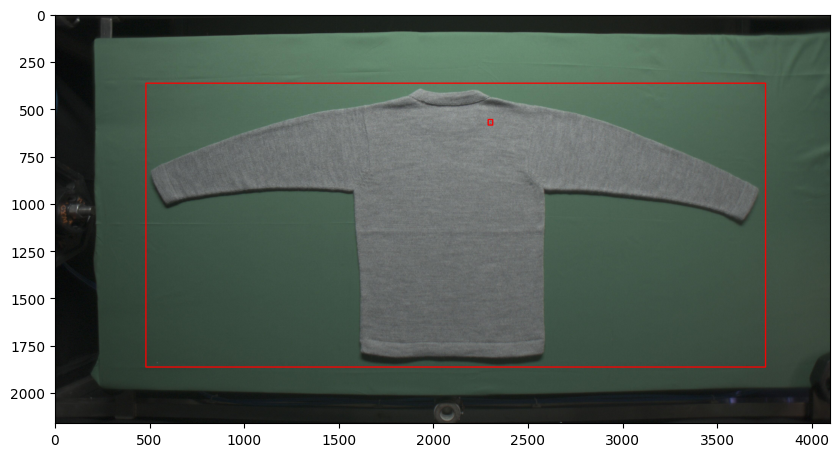

In [9]:
import matplotlib.pyplot as plt

def visualizar_ejemplo(img_path, label_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    with open(label_path, 'r') as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.split())
            # Convertir de formato YOLO (relativo 0-1) a píxeles
            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 5)
    
    plt.figure(figsize=(10,10))
    plt.imshow(img)
    plt.show()

# Prueba con una imagen aumentada al azar
visualizar_ejemplo('dataset_final/train_aug/images/tmp__hpm12e_jpg.rf.e5584426ae1f829c14839bec66b8c1da_aug_0.jpg', 
                  'dataset_final/train_aug/labels/tmp__hpm12e_jpg.rf.e5584426ae1f829c14839bec66b8c1da_aug_0.txt')

In [10]:
import yaml
import os

# Define las rutas absolutas o relativas desde donde ejecutarás el entrenamiento
# Es mejor usar rutas completas para evitar errores de "File Not Found"
dataset_path = os.path.abspath("dataset_final")

data_config = {
    'path': dataset_path,      # Directorio raíz del dataset
    'train': 'train_aug/images',   # Ruta relativa a 'path' para entrenamiento
    'val': 'valid/images',     # Ruta relativa a 'path' para validación
    'test': 'test/images',     # Ruta relativa a 'path' para pruebas (opcional)
    
    'nc': 3,                   # Número de clases
    'names': ['Corrido', 'Hueco','chompa'] # Asegúrate de que este orden sea el mismo de Roboflow
}

# Guardar el archivo
with open('data.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("Archivo data.yaml creado con éxito.")

Archivo data.yaml creado con éxito.


In [5]:
import torch
from ultralytics import YOLO
import os
import gc

def clear_gpu():
    torch.cuda.empty_cache()
    gc.collect()
    # Forzamos a que PyTorch no sea tan rígido con la memoria en la serie 50
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

if __name__ == '__main__':
    clear_gpu()

    # Cargamos la versión 11 Medium
    model = YOLO('yolo11m.pt') 
    
    # Entrenamiento
    model.train(
        data='data.yaml',
        epochs=150,           # Más tiempo para refinamiento final
        imgsz=1280,
        batch=2,
        workers=2,
        
        # --- PARÁMETROS DE PRECISIÓN INDUSTRIAL ---
        cls=2.5,              # Penaliza más la confusión entre clases (Hueco vs Corrido)
        box=7.5,              # Mayor peso a la exactitud de la caja
        dfl=1.5,              # Mejora la detección de bordes finos
        cos_lr=True,          # Descenso de aprendizaje suave para evitar saltos
        patience=50,
        
        # --- ESTRATEGIA DE AUMENTACIÓN VÁLIDA ---
        hsv_h=0.015,
        hsv_s=0.0,            # Entrenamos en escala de grises para enfocar en la textura
        hsv_v=0.4,            # Variación de brillo para ignorar sombras de arrugas
        
        # Usamos Mixup para que el modelo aprenda a distinguir texturas complejas
        mixup=0.1,            
        
        translate=0.1,
        scale=0.3,            # Escala baja para mantener la nitidez de los corridos
        fliplr=0.5,
        flipud=0.0,
        mosaic=0.0,           # Mantenemos desactivado para evitar errores de escala
        rect=True,

        label_smoothing=0.1,  # Ayuda a que el modelo no sea tan rígido y mejore la precisión en clases difíciles
        nbs=64,               # Nominal batch size para estabilizar gradientes
        overlap_mask=False,   # Importante si los defectos están muy cerca uno del otro
        
        # --- HARDWARE ---
        cache=False,
        device=0,
        name='chompas_v11_m'
    )

New https://pypi.org/project/ultralytics/8.4.46 available  Update with 'pip install -U ultralytics'
WARNING 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.241  Python-3.12.12 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.0, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=

In [4]:
metrics = model.val(conf=0.7)  # Filtra detecciones dudosas para maximizar precisión
print(metrics.results_dict['metrics/precision(B)'])

Ultralytics 8.3.241  Python-3.12.12 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8151MiB)
YOLO11m summary (fused): 125 layers, 20,032,345 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1937.8696.8 MB/s, size: 1100.7 KB)
val: Scanning C:\Users\USER\Desktop\clothes-failures-detection\Notebooks\dataset_final\valid\labels.cache... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6s/it 3.2s9.5s
                   all         20        401      0.915      0.489      0.698      0.484
               Corrido         13        295      0.966      0.386      0.679      0.385
                 Hueco         13         86      0.778     0.0814      0.421      0.221
                chompa         20         20          1          1      0.995      0.844
Speed: 8.1ms preprocess, 32.4ms inference, 0.0ms loss, 0.7ms postprocess p